In [1]:
import matplotlib.pyplot as plt

In [ ]:
# !pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


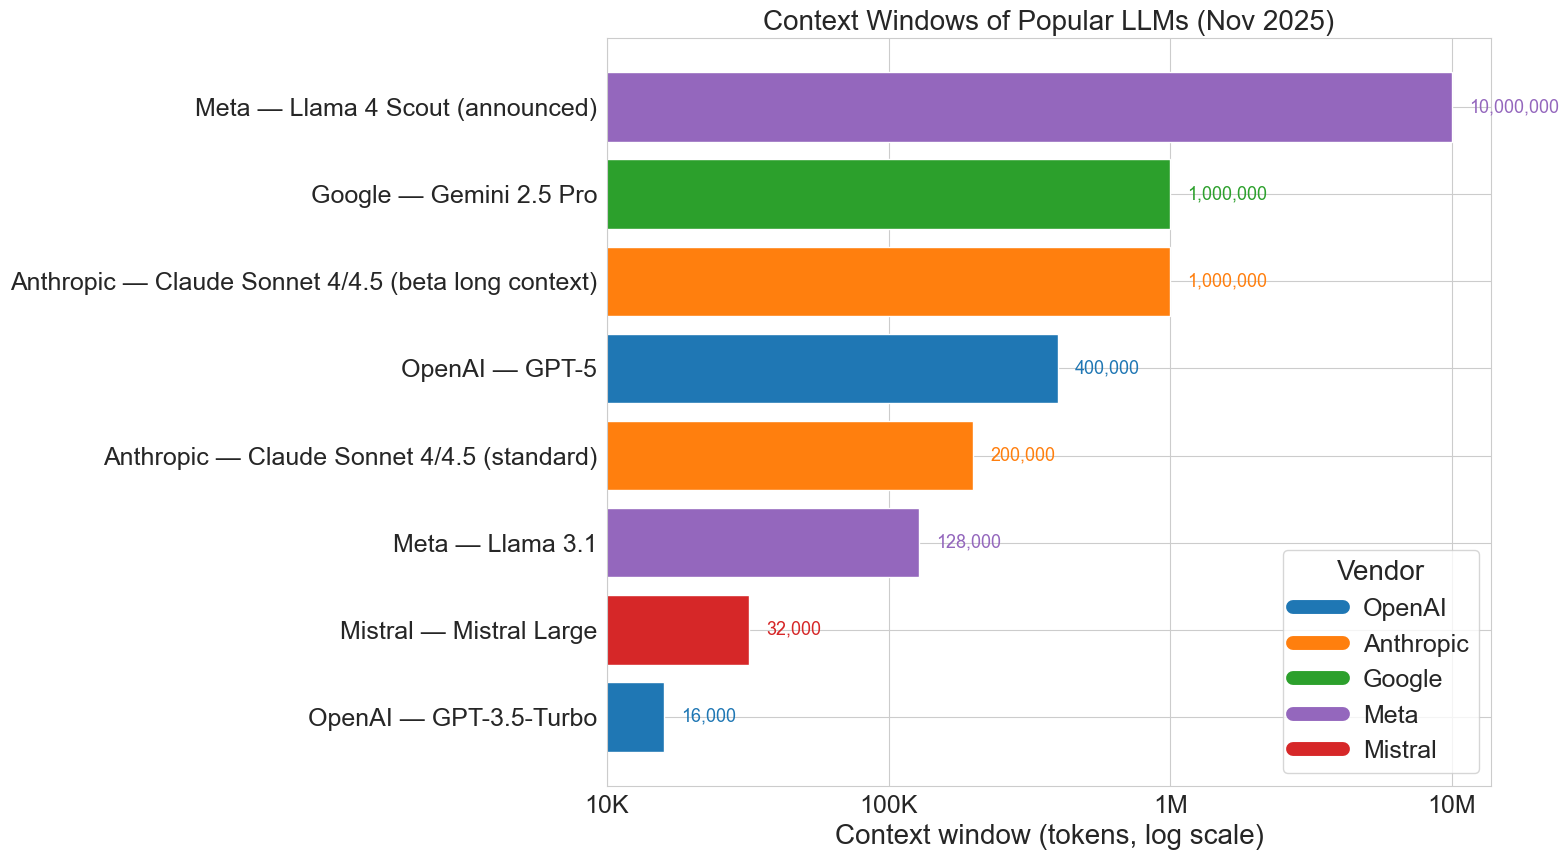

In [17]:
import matplotlib.pyplot as plt

# Data: (label, context tokens, vendor)
models = [
    ("OpenAI — GPT-5", 400_000, "OpenAI"),
    ("OpenAI — GPT-3.5-Turbo", 16_000, "OpenAI"),
    ("Anthropic — Claude Sonnet 4/4.5 (standard)", 200_000, "Anthropic"),
    ("Anthropic — Claude Sonnet 4/4.5 (beta long context)", 1_000_000, "Anthropic"),
    ("Google — Gemini 2.5 Pro", 1_000_000, "Google"),
    ("Meta — Llama 3.1", 128_000, "Meta"),
    ("Meta — Llama 4 Scout (announced)", 10_000_000, "Meta"),
    ("Mistral — Mistral Large", 32_000, "Mistral")
]

# Extract fields
labels = [m[0] for m in models]
values = [m[1] for m in models]
vendors = [m[2] for m in models]

# Vendor color mapping
vendor_colors = {
    "OpenAI": "#1f77b4",      # blue
    "Anthropic": "#ff7f0e",   # orange
    "Google": "#2ca02c",      # green
    "Meta": "#9467bd",        # purple
    "Mistral": "#d62728"      # red
}

# Sort ascending for horizontal layout
order = sorted(range(len(values)), key=lambda i: values[i])
ordered_labels = [labels[i] for i in order]
ordered_values = [values[i] for i in order]
ordered_vendors = [vendors[i] for i in order]
ordered_colors = [vendor_colors[v] for v in ordered_vendors]

# Make wider figure with larger fonts
plt.figure(figsize=(16, 9))
plt.rcParams.update({
    "font.size": 20,         # base font size
    "axes.titlesize": 20,    # title
    "axes.labelsize": 20,    # axis labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

# Plot
bars = plt.barh(ordered_labels, ordered_values, color=ordered_colors)
plt.xscale("log")

plt.xlabel("Context window (tokens, log scale)")
plt.title("Context Windows of Popular LLMs (Nov 2025)")

# Custom x-axis ticks
plt.xticks([1e4, 1e5, 1e6, 1e7], ["10K", "100K", "1M", "10M"])

# Annotate bars
for idx, (val, vendor) in enumerate(zip(ordered_values, ordered_vendors)):
    plt.text(val * 1.15, idx, f"{val:,}", va="center", color=vendor_colors[vendor], fontsize=13)

# Legend
legend_handles = [
    plt.Line2D([0], [0], color=color, lw=10, label=vendor)
    for vendor, color in vendor_colors.items()
]
plt.legend(handles=legend_handles, title="Vendor", loc="lower right")

plt.tight_layout()
plt.savefig('../figures/context_window_comparison.png', dpi=600)
plt.show()


